In [1]:
import os
import numpy as np
from scipy.interpolate import RegularGridInterpolator
import sys
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from getdist import plots, loadMCSamples
from matplotlib import cm
from matplotlib.lines import Line2D
import math
from pathlib import Path

In [2]:


# A global dictionary to cache the loaded data so it only loads once
_likelihood_data = {}

def _initialize_likelihood_data():
    """Loads the gridded and MCMC data into memory the first time it is needed."""
    if _likelihood_data.get('initialized'):
        return

    print("Loading data for the first time... this will take a moment.")
    notebook_dir = Path.cwd()
    base_path = notebook_dir.parents[1] / "data"
    
    # =======================================================
    # 1. Load Gridded Data (P-LB-BK18)
    # =======================================================
    grid_path = os.path.join(base_path, 'rns_code/')
    grid_prefix = 'BK18'
    
    xy = np.loadtxt(os.path.join(grid_path, grid_prefix + 'density_xy.txt'))
    P = np.loadtxt(os.path.join(grid_path, grid_prefix + 'density_P.txt'))
    levels = np.loadtxt(os.path.join(grid_path, grid_prefix + 'density_levels.txt'))
    
    x_grid = xy[:, 0]
    y_grid = xy[:, 1]
    
    # RegularGridInterpolator requires strictly ascending axes
    idx_x = np.argsort(x_grid)
    idx_y = np.argsort(y_grid)
    
    sorted_x = x_grid[idx_x]
    sorted_y = y_grid[idx_y]
    sorted_P = P[idx_y, :][:, idx_x]
    
    # Create the 2D Interpolator
    interp_grid = RegularGridInterpolator(
        (sorted_y, sorted_x), 
        sorted_P, 
        bounds_error=False, 
        fill_value=0.0
    )
    
    _likelihood_data['interp_grid'] = interp_grid
    
    # Higher density threshold = smaller inner area (1-sigma)
    _likelihood_data['level_1sigma_grid'] = max(levels[0], levels[1])
    _likelihood_data['level_2sigma_grid'] = min(levels[0], levels[1])
    
    # =======================================================
    # 2. Load MCMC Data (P-ACT-LB-BK18)
    # =======================================================
    path_p_act_lb = os.path.join(base_path, 'p-actlite-bk-l-b_r_camb/')
    root_p_act_lb = 'p-actlite-bk-l-b_r_camb'
    
    # Load the samples and generate the 2D density
    samples_p_act = loadMCSamples(os.path.join(path_p_act_lb, root_p_act_lb))
    density_p_act = samples_p_act.get2DDensity('ns', 'r')
    
    _likelihood_data['density_p_act'] = density_p_act
    
    # Explicitly calculate the density levels for 1-sigma (68.27%) and 2-sigma (95.45%)
    contours = density_p_act.getContourLevels([0.6827, 0.9545])
    
    # 1-sigma requires higher probability density, 2-sigma requires lower probability density
    _likelihood_data['level_1sigma_act'] = max(contours)
    _likelihood_data['level_2sigma_act'] = min(contours)
    
    _likelihood_data['initialized'] = True
    print("Data successfully loaded!")

def likelihood(ns, r):
    """
    Evaluates whether (ns, r) is within 1-sigma, 2-sigma, or outside.
    Returns a 2-digit integer:
      - 1st digit: P-LB-BK18 status
      - 2nd digit: P-ACT-LB-BK18 status
      (1 = inside 1-sigma, 2 = inside 2-sigma, 3 = outside 2-sigma)
    """
    # Ensure data is loaded
    _initialize_likelihood_data()
    
    # ---------------------------------------------------
    # Check Dataset 1: P-LB-BK18
    # ---------------------------------------------------
    # interp_grid requires arguments in the order of the axes (y, x) -> (r, ns)
    p_val_grid = _likelihood_data['interp_grid']((r, ns))
    
    # SAFELY CONVERT 0-d ARRAY TO FLOAT
    p_val_grid = float(p_val_grid)
        
    if p_val_grid >= _likelihood_data['level_1sigma_grid']:
        digit1 = 1
    elif p_val_grid >= _likelihood_data['level_2sigma_grid']:
        digit1 = 2
    else:
        digit1 = 3
        
    # ---------------------------------------------------
    # Check Dataset 2: P-ACT-LB-BK18
    # ---------------------------------------------------
    # getdist's density.Prob requires (x, y) -> (ns, r)
    p_val_act = float(_likelihood_data['density_p_act'].Prob(ns, r))
    
    if p_val_act >= _likelihood_data['level_1sigma_act']:
        digit2 = 1
    elif p_val_act >= _likelihood_data['level_2sigma_act']:
        digit2 = 2
    else:
        digit2 = 3
        
    # Combine the digits and return as an integer
    return int(f"{digit1}{digit2}")

In [3]:
_running_likelihood_data = {}

def _initialize_running_likelihood_data():
    """Loads the Planck and P-ACT-LB data into memory the first time it is needed."""
    if _running_likelihood_data.get('initialized'):
        return

    print("Loading data for the first time... this will take a moment.")
    notebook_dir = Path.cwd()
    base_dir = notebook_dir.parents[1] / "data"
    
    # =======================================================
    # 1. Load Dataset 1: Planck 2018
    # =======================================================
    # Path taken directly from your alpha_s_4.ipynb notebook
    planck_path = os.path.join(base_dir, 'COM_CosmoParams_fullGrid_R3.01', 'base_nrun', 'plikHM_TTTEEE_lowl_lowE', 'base_nrun_plikHM_TTTEEE_lowl_lowE')
    
    samples_planck = loadMCSamples(planck_path, settings={'ignore_rows': 0.3})
    
    # Extract the 2D density using the parameter names 'ns' and 'nrun'
    density_planck = samples_planck.get2DDensity('ns', 'nrun')
    _running_likelihood_data['density_planck'] = density_planck
    
    # Calculate density levels for 1-sigma (68.27%) and 2-sigma (95.45%)
    contours_planck = density_planck.getContourLevels([0.6827, 0.9545])
    
    # 1-sigma requires higher probability density, 2-sigma requires lower probability density
    _running_likelihood_data['level_1sigma_planck'] = max(contours_planck)
    _running_likelihood_data['level_2sigma_planck'] = min(contours_planck)
    
    # =======================================================
    # 2. Load Dataset 2: P-ACT-LB
    # =======================================================
    # Path taken directly from your alpha_s_4.ipynb notebook
    act_path = os.path.join(base_dir, 'p-actlite-l-b_nrun_camb', 'p-actlite-l-b_nrun_camb')
    
    samples_act = loadMCSamples(act_path, settings={'ignore_rows': 0.3})
    
    density_act = samples_act.get2DDensity('ns', 'nrun')
    _running_likelihood_data['density_act'] = density_act
    
    contours_act = density_act.getContourLevels([0.6827, 0.9545])
    
    _running_likelihood_data['level_1sigma_act'] = max(contours_act)
    _running_likelihood_data['level_2sigma_act'] = min(contours_act)
    
    _running_likelihood_data['initialized'] = True
    print("Data successfully loaded!")

def running_likelihood(alphas, ns):
    """
    Evaluates whether (alphas, ns) is within 1-sigma, 2-sigma, or outside.
    Returns a 2-digit integer:
      - 1st digit: Planck 2018 status
      - 2nd digit: P-ACT-LB status
      (1 = inside 1-sigma, 2 = inside 2-sigma, 3 = outside 2-sigma)
    """
    # Ensure data is loaded
    _initialize_running_likelihood_data()
    
    # ---------------------------------------------------
    # Check Dataset 1: Planck 2018
    # ---------------------------------------------------
    # getdist's density.Prob requires arguments in the order of initialization: (ns, nrun)
    p_val_planck = float(_running_likelihood_data['density_planck'].Prob(ns, alphas))
        
    if p_val_planck >= _running_likelihood_data['level_1sigma_planck']:
        digit1 = 1
    elif p_val_planck >= _running_likelihood_data['level_2sigma_planck']:
        digit1 = 2
    else:
        digit1 = 3
        
    # ---------------------------------------------------
    # Check Dataset 2: P-ACT-LB
    # ---------------------------------------------------
    p_val_act = float(_running_likelihood_data['density_act'].Prob(ns, alphas))
    
    if p_val_act >= _running_likelihood_data['level_1sigma_act']:
        digit2 = 1
    elif p_val_act >= _running_likelihood_data['level_2sigma_act']:
        digit2 = 2
    else:
        digit2 = 3
        
    # Combine the digits and return as an integer
    return int(f"{digit1}{digit2}")

In [4]:
def phi2_final(c):
    """
    Calculates phi^2_final based on the coupling constant c (xi).
    
    Formula:
    1 / (8*c + 3*sqrt(c*(c + 18) + 9) + 9)
    """
    xi = c
    
    # Calculate the term inside the square root first
    # xi * (xi + 18) + 9
    sqrt_arg = xi * (xi + 18) + 9
    sqrt_term = np.sqrt(sqrt_arg)
    
    # Calculate the denominator
    # 8*xi + 3*sqrt(...) + 9
    denominator = 8 * xi + 3 * sqrt_term + 9
    
    return 1.0 / denominator

In [5]:
def phi2_initial(N, c):
    """
    Calculates phi^2_initial based on N and c (xi).
    
    Formula:
    (0.0909091 - 0.0909091 * exp(-7.3332 * xi * N) * (1 - 11 * xi * phi_f^2)^0.999981) / xi
    """
    # 1. Get phi_final squared
    phi_f_sq = phi2_final(c)
    
    # 2. Define xi
    xi = c
    
    # 3. Calculate the base term for the exponent
    # (1. - 11. * xi * phi_f^2)
    base_term = 1.0 - 11.0 * xi * phi_f_sq
    
    # 4. Calculate the exponential part
    # exp(-7.3332 * xi * N)
    exp_part = np.exp(-7.3332 * xi * N)
    
    # 5. Combine terms in the numerator
    # 0.0909091 * exp_part * base_term^0.999981
    term2 = 0.0909091 * exp_part * (base_term**0.999981)
    
    # Numerator: 0.0909091 - term2
    numerator = 0.0909091 - term2
    
    # 6. Final result
    return numerator / xi

In [6]:
def ns(N, c):
    """
    Calculates the scalar spectral index n_s based on N and c (xi)
    using specific numerical constants.
    
    Formula:
    xi * ( (7.9997 / (1. * xi * phi_i^2 + 1.)) - 13.4442 ) - (0.777776 / phi_i^2) + 0.99985
    """
    # 1. Get phi_initial squared
    phi_i_sq = phi2_initial(N, c)
    
    # 2. Define xi
    xi = c
    
    # 3. Calculate the bracket term
    # (7.9997 / (1. * xi * phi_i^2 + 1.)) - 13.4442
    denom = (1.0 * xi * phi_i_sq) + 1.0
    bracket = (7.9997 / denom) - 13.4442
    
    # 4. Calculate the main terms
    term1 = xi * bracket
    term2 = 0.777776 / phi_i_sq
    term3 = 0.99985
    
    # 5. Final result
    return term1 - term2 + term3

In [7]:
def r(N, c):
    """
    Calculates the tensor-to-scalar ratio r based on N and c (xi)
    using specific numerical constants.
    
    Formula:
    xi * ( 107.552 - (127.995 / (1. * xi * phi_i^2 + 1.)) ) + (0.888856 / phi_i^2)
    """
    # 1. Get phi_initial squared
    phi_i_sq = phi2_initial(N, c)
    
    # 2. Define xi
    xi = c
    
    # 3. Calculate the bracket term
    # 107.552 - (127.995 / (1. * xi * phi_i^2 + 1.))
    denom = (1.0 * xi * phi_i_sq) + 1.0
    bracket = 107.552 - (127.995 / denom)
    
    # 4. Calculate the main terms
    term1 = xi * bracket
    term2 = 0.888856 / phi_i_sq
    
    # 5. Final result
    return term1 + term2

In [8]:
def alpha(N, c):
    """
    Calculates the running of the scalar spectral index alpha_s 
    based on N and c (xi).
    """
    # 1. Get phi_final squared
    phi_f_sq = phi2_final(c)
    
    # 2. Define xi and base terms
    xi = c
    base_term = 1.0 - 11.0 * xi * phi_f_sq
    
    # 3. Calculate exponential factor E = exp(7.3332 * xi * N)
    # The formula uses multiples: 7.3332, 14.6664 (2x), 21.9996 (3x)
    E = np.exp(7.3332 * xi * N)
    E2 = E**2  # exp(14.6664 * xi * N)
    E3 = E**3  # exp(21.9996 * xi * N)
    
    # --- NUMERATOR ---
    # Common factor: xi^2
    
    # Term 1: -3.44709 * E * base^2.99994
    n1 = -3.44709 * E * (base_term**2.99994)
    
    # Term 2: -1.27309 * E^2 * base^1.99996
    n2 = -1.27309 * E2 * (base_term**1.99996)
    
    # Term 3: 49.6401 * E^3 * base^0.999981
    n3 = 49.6401 * E3 * (base_term**0.999981)
    
    numerator = (xi**2) * (n1 + n2 + n3)
    
    # --- DENOMINATOR ---
    # The whole expression is squared at the end
    
    # Term 1: 0.0769231 * base^1.99996
    d1 = 0.0769231 * (base_term**1.99996)
    
    # Term 2: -1. * E * base^0.999981
    d2 = -1.0 * E * (base_term**0.999981)
    
    # Term 3: 0.923077 * E^2
    d3 = 0.923077 * E2
    
    denominator = (d1 + d2 + d3)**2
    
    return numerator / denominator

In [9]:
N_list = np.linspace(0,140,1000)
c_list = np.linspace(10**(-8),10**(-2),1000)

In [10]:
N_p_lb_bk_1 = []
c_p_lb_bk_1 = []
N_p_lb_bk_2 = []
c_p_lb_bk_2 = []
N_p_act_lb_bk_1 = []
c_p_act_lb_bk_1 = []
N_p_act_lb_bk_2 = []
c_p_act_lb_bk_2 = []

N_p_lb_bk_1_alpha = []
c_p_lb_bk_1_alpha = []
N_p_lb_bk_2_alpha = []
c_p_lb_bk_2_alpha = []
N_p_act_lb_bk_1_alpha = []
c_p_act_lb_bk_1_alpha = []
N_p_act_lb_bk_2_alpha = []
c_p_act_lb_bk_2_alpha = []

In [11]:
for c in c_list:
    for N in N_list:
        nsval = ns(N,c)
        rval = r(N,c)
        alphaval = alpha(N, c)
        likeval = likelihood(nsval, rval)
        runlikeval = running_likelihood(alphaval, nsval)
        
        if (int(str(likeval)[0])==1):
            N_p_lb_bk_1.append(N)
            c_p_lb_bk_1.append(c)
        elif (int(str(likeval)[0])==2):
            N_p_lb_bk_2.append(N)
            c_p_lb_bk_2.append(c)

        if (int(str(likeval)[1])==1):
            N_p_act_lb_bk_1.append(N)
            c_p_act_lb_bk_1.append(c)
        elif (int(str(likeval)[1])==2):
            N_p_act_lb_bk_2.append(N)
            c_p_act_lb_bk_2.append(c)


        if (int(str(runlikeval)[0])==1):
            N_p_lb_bk_1_alpha.append(N)
            c_p_lb_bk_1_alpha.append(c)
        elif (int(str(runlikeval)[0])==2):
            N_p_lb_bk_2_alpha.append(N)
            c_p_lb_bk_2_alpha.append(c)

        if (int(str(runlikeval)[1])==1):
            N_p_act_lb_bk_1_alpha.append(N)
            c_p_act_lb_bk_1_alpha.append(c)
        elif (int(str(runlikeval)[1])==2):
            N_p_act_lb_bk_2_alpha.append(N)
            c_p_act_lb_bk_2_alpha.append(c)

Loading data for the first time... this will take a moment.
Data successfully loaded!
Loading data for the first time... this will take a moment.
Data successfully loaded!


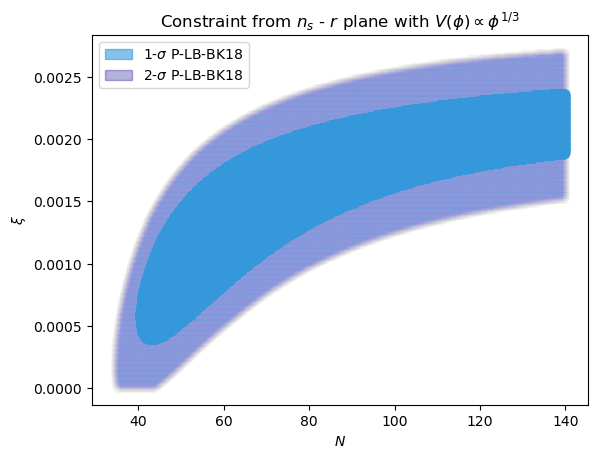

In [12]:
plt.xlabel(r'$N$')
plt.ylabel(r'$\xi$')
plt.title(r'Constraint from $n_s$ - $r$ plane with $V(\phi)\propto\phi^{1/3}$')
plt.scatter(N_p_lb_bk_1, c_p_lb_bk_1,color='#3498DB',alpha=1)
plt.scatter(N_p_lb_bk_2, c_p_lb_bk_2,color='#3498DB',alpha=0.003)

legend_elements = [
    mpatches.Patch(color='#3498DB', alpha=0.6, label=r'1-$\sigma$ P-LB-BK18'),
    mpatches.Patch(color='darkblue', alpha=0.3, label=r'2-$\sigma$ P-LB-BK18')
]

# 3. Add the custom legend to the plot
plt.legend(handles=legend_elements)

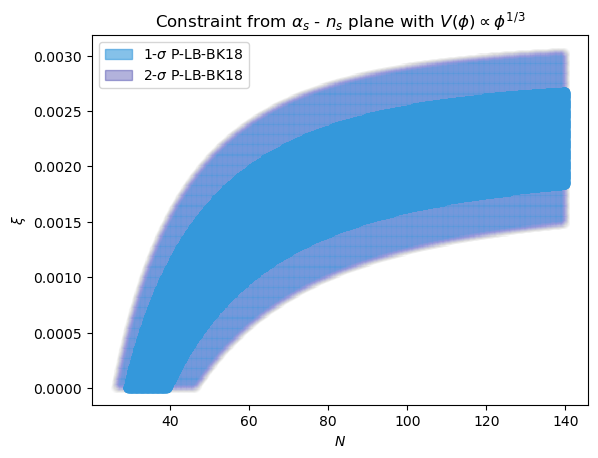

In [13]:
plt.xlabel(r'$N$')
plt.ylabel(r'$\xi$')
plt.title(r'Constraint from $\alpha_s$ - $n_s$ plane with $V(\phi)\propto\phi^{1/3}$')
plt.scatter(N_p_lb_bk_1_alpha, c_p_lb_bk_1_alpha,color='#3498DB',alpha=1)
plt.scatter(N_p_lb_bk_2_alpha, c_p_lb_bk_2_alpha,color='#3498DB',alpha=0.003)

legend_elements = [
    mpatches.Patch(color='#3498DB', alpha=0.6, label=r'1-$\sigma$ P-LB-BK18'),
    mpatches.Patch(color='darkblue', alpha=0.3, label=r'2-$\sigma$ P-LB-BK18')
]

# 3. Add the custom legend to the plot
plt.legend(handles=legend_elements)

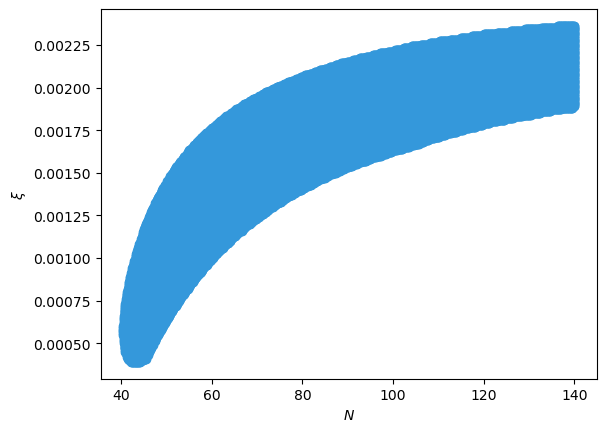

In [14]:
full_sigma_1_ns = []
full_sigma_1_alphas = []
for i in range(0,len(N_p_lb_bk_1)):
    full_sigma_1_ns.append([N_p_lb_bk_1[i],c_p_lb_bk_1[i]])
    
for i in range(0,len(N_p_lb_bk_1_alpha)):
    full_sigma_1_alphas.append([N_p_lb_bk_1_alpha[i],c_p_lb_bk_1_alpha[i]])

sigma_1_pair = [item for item in full_sigma_1_ns if item in full_sigma_1_alphas]

sigma_1_N = []
sigma_1_c = []
for i in range(0,len(sigma_1_pair)):
    sigma_1_N.append(sigma_1_pair[i][0])
    sigma_1_c.append(sigma_1_pair[i][1])

plt.xlabel(r'$N$')
plt.ylabel(r'$\xi$')
plt.scatter(sigma_1_N,sigma_1_c,color='#3498DB')

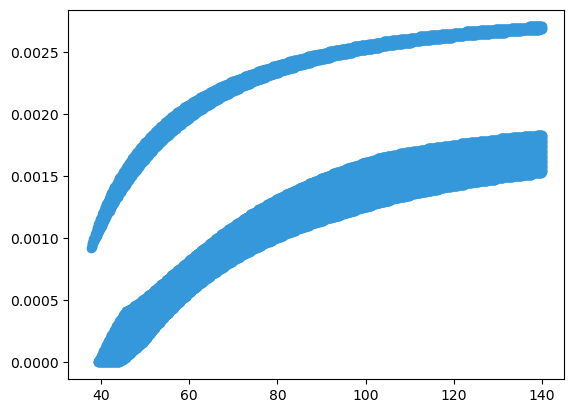

In [15]:
full_sigma_2_ns = []
full_sigma_2_alphas = []
for i in range(0,len(N_p_lb_bk_2)):
    full_sigma_2_ns.append([N_p_lb_bk_2[i],c_p_lb_bk_2[i]])
    
for i in range(0,len(N_p_lb_bk_2_alpha)):
    full_sigma_2_alphas.append([N_p_lb_bk_2_alpha[i],c_p_lb_bk_2_alpha[i]])

sigma_2_pair = [item for item in full_sigma_2_ns if item in full_sigma_2_alphas]

sigma_2_N = []
sigma_2_c = []
for i in range(0,len(sigma_2_pair)):
    sigma_2_N.append(sigma_2_pair[i][0])
    sigma_2_c.append(sigma_2_pair[i][1])

plt.scatter(sigma_2_N,sigma_2_c,color='#3498DB')

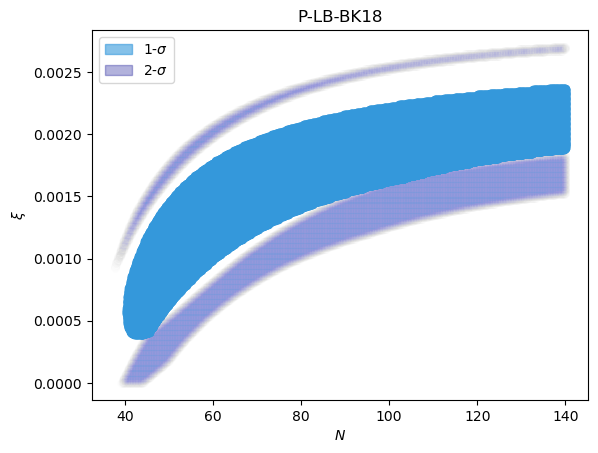

In [16]:
plt.xlabel(r'$N$')
plt.ylabel(r'$\xi$')
plt.title('P-LB-BK18')
plt.scatter(sigma_1_N,sigma_1_c,color='#3498DB',alpha=1)
plt.scatter(sigma_2_N,sigma_2_c,color='#3498DB',alpha=0.003)

legend_elements = [
    mpatches.Patch(color='#3498DB', alpha=0.6, label=r'1-$\sigma$'),
    mpatches.Patch(color='darkblue', alpha=0.3, label=r'2-$\sigma$')
]

# 3. Add the custom legend to the plot
plt.legend(handles=legend_elements)

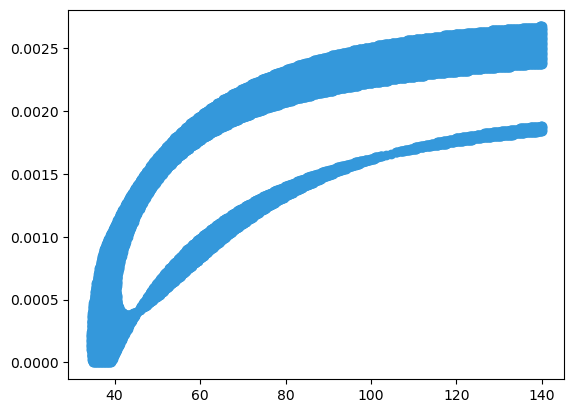

In [17]:
sigma_12_pair = [item for item in full_sigma_1_ns if item in full_sigma_2_alphas]
sigma_21_pair = [item for item in full_sigma_2_ns if item in full_sigma_1_alphas]

sigma_cross_pair = sigma_12_pair + sigma_21_pair

sigma_cross_N = []
sigma_cross_c = []
for i in range(0,len(sigma_cross_pair)):
    sigma_cross_N.append(sigma_cross_pair[i][0])
    sigma_cross_c.append(sigma_cross_pair[i][1])

plt.scatter(sigma_cross_N,sigma_cross_c,color='#3498DB')

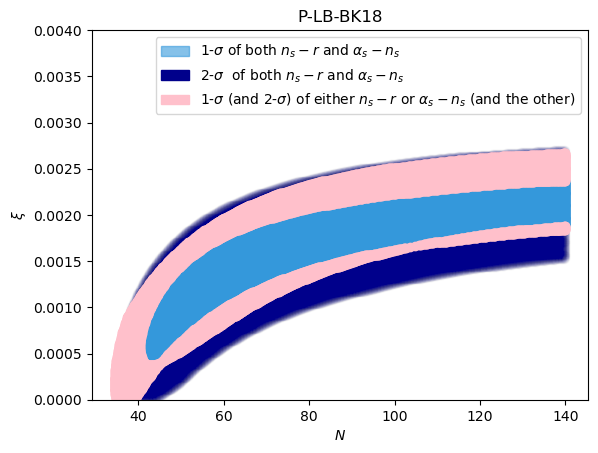

In [18]:
plt.xlabel(r'$N$')
plt.ylabel(r'$\xi$')
plt.title('P-LB-BK18')
plt.ylim(0,0.004)
plt.scatter(sigma_1_N,sigma_1_c,color='#3498DB',alpha=1)
plt.scatter(sigma_2_N,sigma_2_c,color='darkblue',alpha=0.01)
plt.scatter(sigma_cross_N,sigma_cross_c,color='pink')

legend_elements = [
    mpatches.Patch(color='#3498DB', alpha=0.6, label=r'1-$\sigma$ of both $n_s-r$ and $\alpha_s-n_s$'),
    mpatches.Patch(color='darkblue', alpha=1, label=r'2-$\sigma$  of both $n_s-r$ and $\alpha_s-n_s$'),
    mpatches.Patch(color='pink', alpha=1, label=r'$1$-$\sigma$ (and $2$-$\sigma$) of either $n_s-r$ or $\alpha_s-n_s$ (and the other)')
]

# 3. Add the custom legend to the plot
plt.legend(handles=legend_elements)
plt.savefig("parameter_1_3_p_lb_bk.pdf", dpi=300)

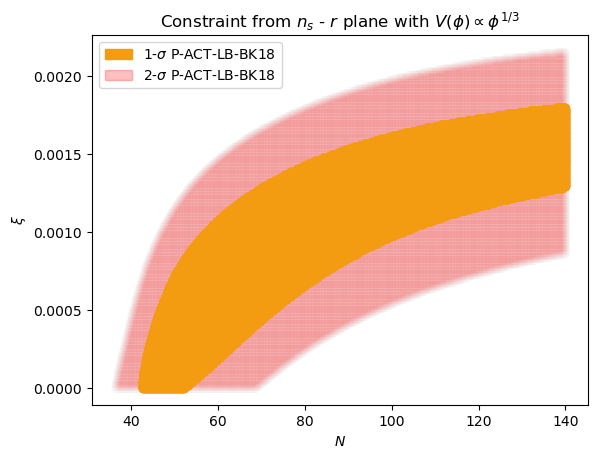

In [19]:
plt.xlabel(r'$N$')
plt.ylabel(r'$\xi$')
plt.title(r'Constraint from $n_s$ - $r$ plane with $V(\phi)\propto\phi^{1/3}$')
plt.scatter(N_p_act_lb_bk_1, c_p_act_lb_bk_1,color='#F39C12', alpha=1)
plt.scatter(N_p_act_lb_bk_2, c_p_act_lb_bk_2,color='#F39C12', alpha=0.003)
legend_elements = [
    mpatches.Patch(color='#F39C12', alpha=1, label=r'1-$\sigma$ P-ACT-LB-BK18'),
    mpatches.Patch(color='red', alpha=0.25, label=r'2-$\sigma$ P-ACT-LB-BK18')
]

# 3. Add the custom legend to the plot
plt.legend(handles=legend_elements)

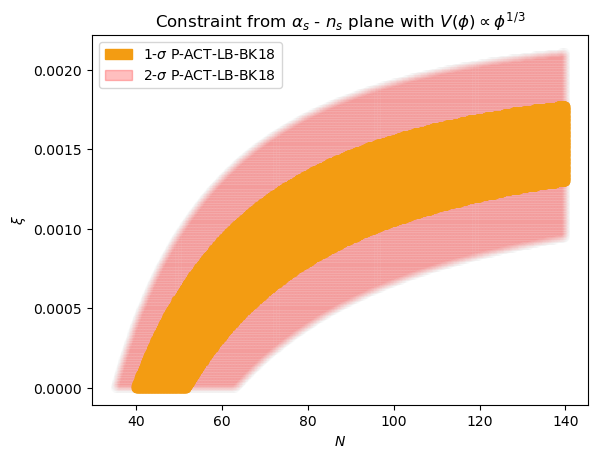

In [20]:
plt.xlabel(r'$N$')
plt.ylabel(r'$\xi$')
plt.title(r'Constraint from $\alpha_s$ - $n_s$ plane with $V(\phi)\propto\phi^{1/3}$')
plt.scatter(N_p_act_lb_bk_1_alpha, c_p_act_lb_bk_1_alpha,color='#F39C12', alpha=1)
plt.scatter(N_p_act_lb_bk_2_alpha, c_p_act_lb_bk_2_alpha,color='#F39C12', alpha=0.003)
legend_elements = [
    mpatches.Patch(color='#F39C12', alpha=1, label=r'1-$\sigma$ P-ACT-LB-BK18'),
    mpatches.Patch(color='red', alpha=0.25, label=r'2-$\sigma$ P-ACT-LB-BK18')
]

# 3. Add the custom legend to the plot
plt.legend(handles=legend_elements)

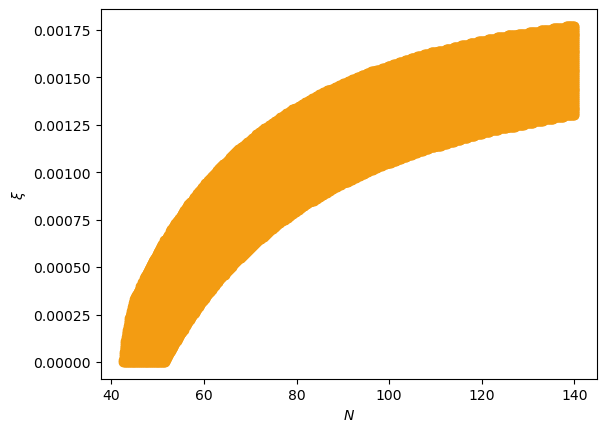

In [21]:
full_sigma_1_ns_act = []
full_sigma_1_alphas_act = []
for i in range(0,len(N_p_act_lb_bk_1)):
    full_sigma_1_ns_act.append([N_p_act_lb_bk_1[i],c_p_act_lb_bk_1[i]])
    
for i in range(0,len(N_p_act_lb_bk_1_alpha)):
    full_sigma_1_alphas_act.append([N_p_act_lb_bk_1_alpha[i],c_p_act_lb_bk_1_alpha[i]])

sigma_1_pair_act = [item for item in full_sigma_1_ns_act if item in full_sigma_1_alphas_act]

sigma_1_N_act = []
sigma_1_c_act = []
for i in range(0,len(sigma_1_pair_act)):
    sigma_1_N_act.append(sigma_1_pair_act[i][0])
    sigma_1_c_act.append(sigma_1_pair_act[i][1])

plt.xlabel(r'$N$')
plt.ylabel(r'$\xi$')
plt.scatter(sigma_1_N_act,sigma_1_c_act,color='#F39C12')

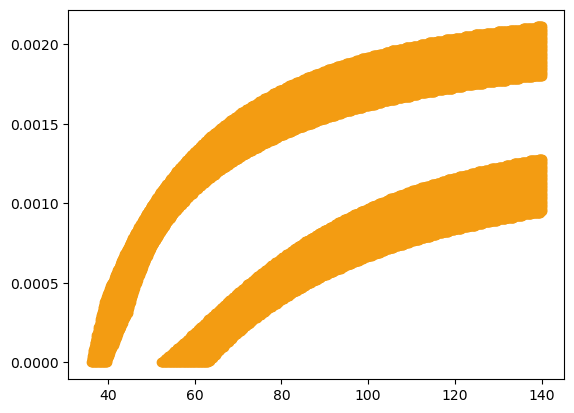

In [22]:
full_sigma_2_ns_act = []
full_sigma_2_alphas_act = []
for i in range(0,len(N_p_act_lb_bk_2)):
    full_sigma_2_ns_act.append([N_p_act_lb_bk_2[i],c_p_act_lb_bk_2[i]])
    
for i in range(0,len(N_p_act_lb_bk_2_alpha)):
    full_sigma_2_alphas_act.append([N_p_act_lb_bk_2_alpha[i],c_p_act_lb_bk_2_alpha[i]])

sigma_2_pair_act = [item for item in full_sigma_2_ns_act if item in full_sigma_2_alphas_act]

sigma_2_N_act = []
sigma_2_c_act = []
for i in range(0,len(sigma_2_pair_act)):
    sigma_2_N_act.append(sigma_2_pair_act[i][0])
    sigma_2_c_act.append(sigma_2_pair_act[i][1])
plt.scatter(sigma_2_N_act,sigma_2_c_act,color='#F39C12')

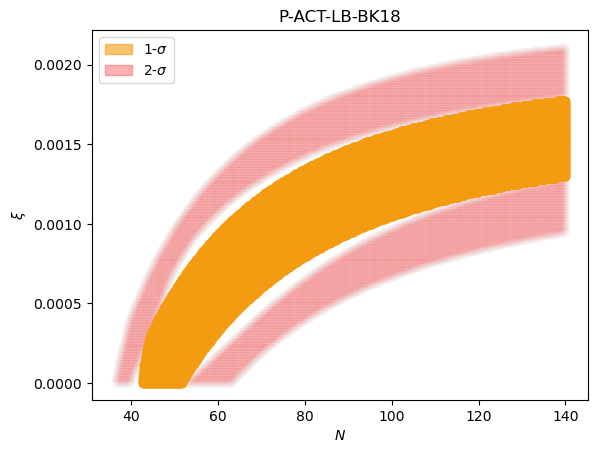

In [23]:
plt.xlabel(r'$N$')
plt.ylabel(r'$\xi$')
plt.title('P-ACT-LB-BK18')
plt.scatter(sigma_1_N_act,sigma_1_c_act,color='#F39C12',alpha=1)
plt.scatter(sigma_2_N_act,sigma_2_c_act,color='#F39C12',alpha=0.003)

legend_elements = [
    mpatches.Patch(color='#F39C12', alpha=0.6, label=r'1-$\sigma$'),
    mpatches.Patch(color='red', alpha=0.3, label=r'2-$\sigma$')
]

# 3. Add the custom legend to the plot
plt.legend(handles=legend_elements)

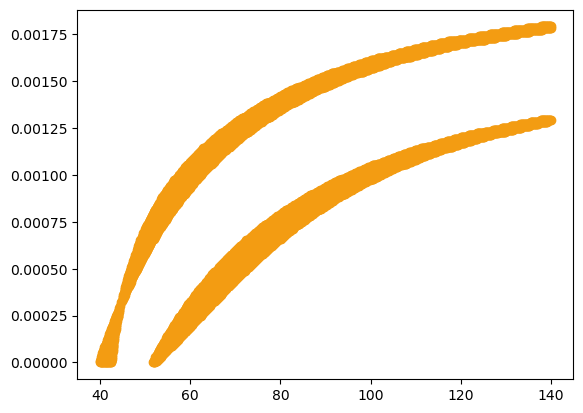

In [24]:
sigma_12_pair_act = [item for item in full_sigma_1_ns_act if item in full_sigma_2_alphas_act]
sigma_21_pair_act = [item for item in full_sigma_2_ns_act if item in full_sigma_1_alphas_act]

sigma_cross_pair_act = sigma_12_pair_act + sigma_21_pair_act

sigma_cross_N_act = []
sigma_cross_c_act = []
for i in range(0,len(sigma_cross_pair_act)):
    sigma_cross_N_act.append(sigma_cross_pair_act[i][0])
    sigma_cross_c_act.append(sigma_cross_pair_act[i][1])

plt.scatter(sigma_cross_N_act,sigma_cross_c_act,color='#F39C12')

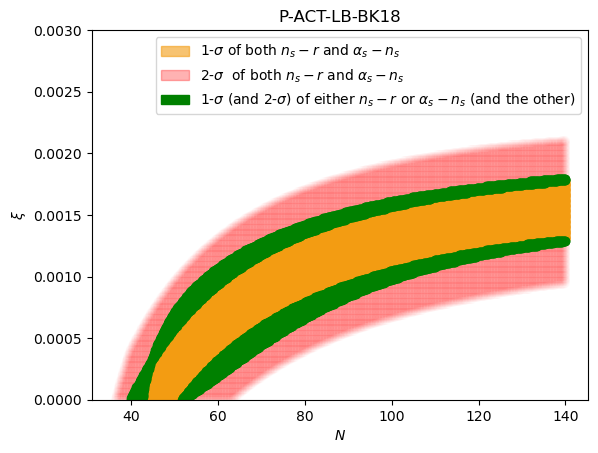

In [25]:
plt.xlabel(r'$N$')
plt.ylabel(r'$\xi$')
plt.title('P-ACT-LB-BK18')
plt.ylim(0,0.003)
plt.scatter(sigma_1_N_act,sigma_1_c_act,color='#F39C12',alpha=1)
plt.scatter(sigma_2_N_act,sigma_2_c_act,color='red',alpha=0.004)
plt.scatter(sigma_cross_N_act,sigma_cross_c_act,color='green')

legend_elements = [
    mpatches.Patch(color='#F39C12', alpha=0.6, label=r'1-$\sigma$ of both $n_s-r$ and $\alpha_s-n_s$'),
    mpatches.Patch(color='red', alpha=0.3, label=r'2-$\sigma$  of both $n_s-r$ and $\alpha_s-n_s$'),
    mpatches.Patch(color='green', alpha=1, label=r'$1$-$\sigma$ (and $2$-$\sigma$) of either $n_s-r$ or $\alpha_s-n_s$ (and the other)')
]

# 3. Add the custom legend to the plot
plt.legend(handles=legend_elements)
plt.savefig("parameter_1_3_p_act_lb_bk.pdf", dpi=300)

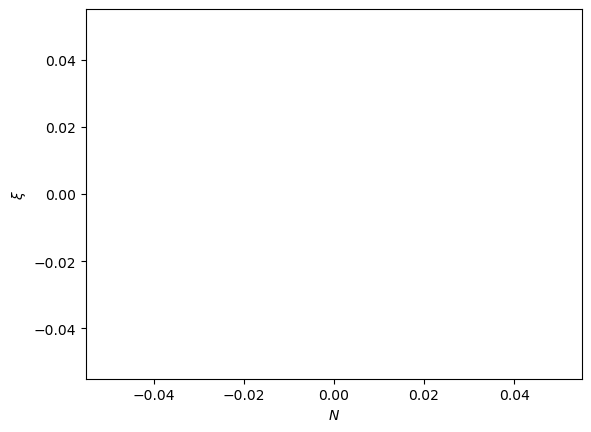

In [26]:
sigma_1_pair_int = [item for item in sigma_1_pair if item in sigma_1_pair_act]

sigma_1_N_int = []
sigma_1_c_int = []
for i in range(0,len(sigma_1_pair_int)):
    sigma_1_N_int.append(sigma_1_pair_int[i][0])
    sigma_1_c_int.append(sigma_1_pair_int[i][1])

plt.xlabel(r'$N$')
plt.ylabel(r'$\xi$')
plt.scatter(sigma_1_N_int,sigma_1_c_int,color='red')

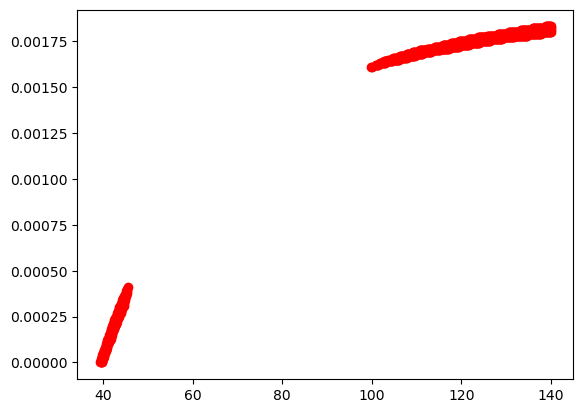

In [27]:
sigma_2_pair_int = [item for item in sigma_2_pair if item in sigma_2_pair_act]

sigma_2_N_int = []
sigma_2_c_int = []
for i in range(0,len(sigma_2_pair_int)):
    sigma_2_N_int.append(sigma_2_pair_int[i][0])
    sigma_2_c_int.append(sigma_2_pair_int[i][1])

plt.scatter(sigma_2_N_int,sigma_2_c_int,color='red')

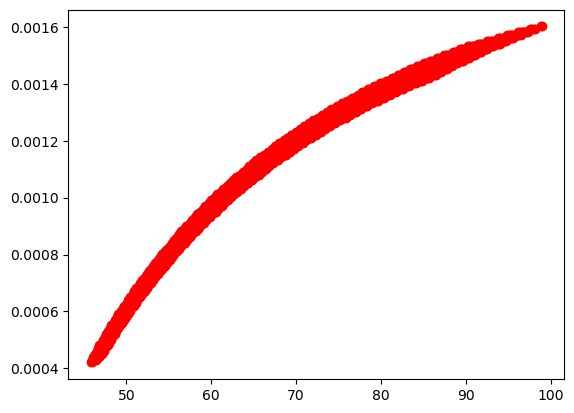

In [28]:
sigma_cross_pair_int = [item for item in sigma_cross_pair if item in sigma_cross_pair_act]

sigma_cross_N_int = []
sigma_cross_c_int = []
for i in range(0,len(sigma_cross_pair_int)):
    sigma_cross_N_int.append(sigma_cross_pair_int[i][0])
    sigma_cross_c_int.append(sigma_cross_pair_int[i][1])

plt.scatter(sigma_cross_N_int,sigma_cross_c_int,color='red')

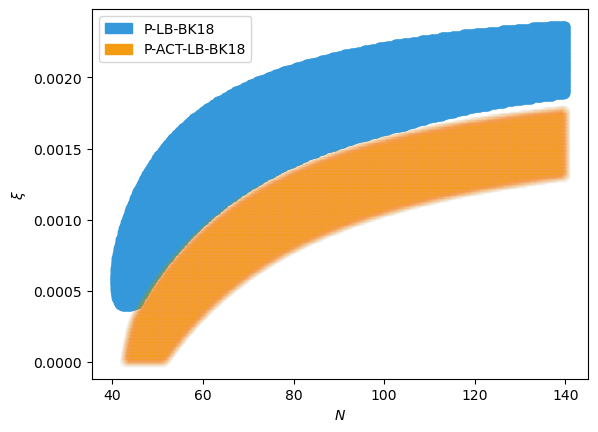

In [29]:
plt.xlabel(r'$N$')
plt.ylabel(r'$\xi$')
#plt.ylim(0,1.2)
plt.scatter(sigma_1_N,sigma_1_c,color='#3498DB')
plt.scatter(sigma_1_N_act,sigma_1_c_act,color='#F39C12', alpha = 0.01)
#plt.plot(50*(np.linspace(0,1.2,1000)**0),np.linspace(0,1.2,1000),color='green')
#plt.plot(70*(np.linspace(0,1.2,1000)**0),np.linspace(0,1.2,1000),color='red')
legend_elements = [
    mpatches.Patch(color='#3498DB', label=r'P-LB-BK18'),
    mpatches.Patch(color='#F39C12', label=r'P-ACT-LB-BK18')
]

# 3. Add the custom legend to the plot
plt.legend(handles=legend_elements)
plt.savefig("sigma_1_3.pdf", dpi=600)

In [30]:
N_table = [60,65,70]
c_table = [0.0005,0.001,0.0015,0.02]

file = open("table_1_3.csv", "x")
file.write(f"{"c"}\t{"N"}\t{"ns"}\t{"r"}\t{"alpha_s"}\t{"ns_status"}\t{"alpha_status"}\n")

for c in c_table:
    for N in N_table:
        ns_num = ns(N, c)
        r_num = r(N, c)
        alpha_num = alpha(N, c)
        ns_status = likelihood(ns_num, r_num)
        alpha_status = running_likelihood(alpha_num, ns_num)
        file.write(f"{c}\t{N}\t{round(ns_num,3)}\t{round(r_num,3)}\t{round(alpha_num,3)}\t{ns_status}\t{alpha_status}\n")
file.close()